In [ ]:
#Lab6
#Hamza ALsihati
#2230006810
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from numpy.fft import fft2, ifft2, ifftshift

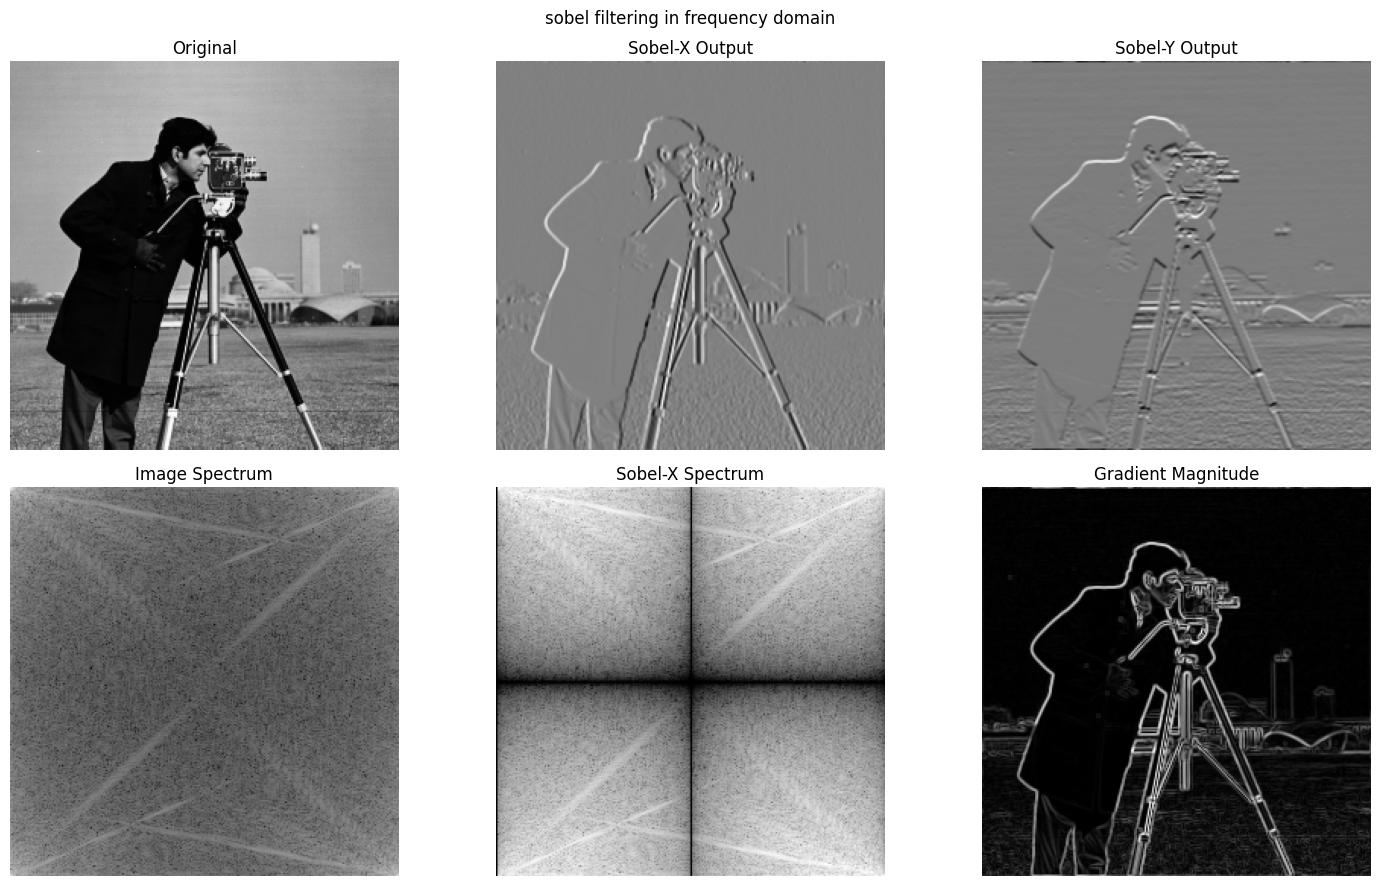

In [6]:
# Load image
img = Image.open('Images/cameraman.tif').convert('L')

# Resize image
image = np.array(img, dtype=np.float64)
image = np.array(Image.fromarray(image).resize((256, 256)))

M, N = image.shape

# Apply sobel
sobel_x = np.array([[-1, 0, 1],[-2, 0, 2],[-1, 0, 1]],dtype=np.float64)
sobel_y = np.array([[-1, -2, -1],[ 0,  0,  0],[ 1,  2,  1]],dtype=np.float64)

def center_embed_kernel(kernel, shape):
    padded = np.zeros(shape)
    kh, kw = kernel.shape
    ph, pw = shape
    cy, cx = ph // 2, pw // 2
    padded[cy - kh//2 : cy - kh//2 + kh, cx - kw//2 : cx - kw//2 + kw] = kernel
    return fft2(ifftshift(padded))


H_x = center_embed_kernel(sobel_x, (M, N))
H_y = center_embed_kernel(sobel_y, (M, N))

F = fft2(image)
F_sobel_x = F * H_x
F_sobel_y = F * H_y

sobel_x_img = ifft2(F_sobel_x).real
sobel_y_img = ifft2(F_sobel_y).real
sobel_magnitude = np.sqrt(sobel_x_img**2 + sobel_y_img**2)

fig, axises = plt.subplots(2, 3, figsize=(15, 9))

axises[0, 0].imshow(image, cmap='gray')
axises[0, 0].set_title('Original')
axises[0, 0].axis('off')

axises[0, 1].imshow(sobel_x_img, cmap='gray')
axises[0, 1].set_title('Sobel-X Output')
axises[0, 1].axis('off')

axises[0, 2].imshow(sobel_y_img, cmap='gray')
axises[0, 2].set_title('Sobel-Y Output')
axises[0, 2].axis('off')

axises[1, 0].imshow(np.log(1 + np.abs(F)), cmap='gray')
axises[1, 0].set_title('Image Spectrum')
axises[1, 0].axis('off')

axises[1, 1].imshow(np.log(1 + np.abs(F_sobel_x)), cmap='gray')
axises[1, 1].set_title('Sobel-X Spectrum')
axises[1, 1].axis('off')

axises[1, 2].imshow(sobel_magnitude, cmap='gray')
axises[1, 2].set_title('Gradient Magnitude')
axises[1, 2].axis('off')

plt.suptitle('sobel filtering in frequency domain')
plt.tight_layout()
plt.show()